<a href="https://colab.research.google.com/github/ProductPriceTrackerOrg/data-science/blob/main/notebooks/GNN/02_building_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heterogeneous GNN for product recommendations**





## **1: Import Libraries and Setup**

- Imports all necessary libraries for data processing, GNN modeling, and visualization
- Sets random seeds to ensure reproducible results across runs
- PyTorch Geometric for GNN operations, SentenceTransformers for text embeddings, sklearn for t-SNE

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.1 MB/s eta 0:00:00


In [3]:
# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.loader import LinkNeighborLoader
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## **2: Load the Data**

In [4]:
# # Cell 2: Create sample DataFrames
# # In real scenario, these would come from your data warehouse queries

# # Product data
# product_df = pd.DataFrame({
#     'shop_product_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
#     'product_title_native': [
#         'iPhone 13 Pro Max',
#         'Samsung Galaxy S21',
#         'Nike Air Jordan',
#         'Adidas Ultraboost',
#         'MacBook Pro 16',
#         'Dell XPS 13',
#         'Sony WH-1000XM4',
#         'Apple AirPods Pro',
#         'Canon EOS R5',
#         'Nikon D850'
#     ]
# })

# # Brand data
# brand_df = pd.DataFrame({
#     'brand_native_name': ['Apple', 'Samsung', 'Nike', 'Adidas', 'Dell', 'Sony', 'Canon', 'Nikon']
# })

# # Category data
# category_df = pd.DataFrame({
#     'category_id': [101, 102, 103, 104, 105],
#     'category_name': ['Smartphones', 'Shoes', 'Laptops', 'Headphones', 'Cameras']
# })

# # Shop data
# shop_df = pd.DataFrame({
#     'shop_id': [201, 202, 203],
#     'shop_name': ['TechStore', 'SportShop', 'ElectronicsHub']
# })

# # Edge relationships
# product_brand_edges_df = pd.DataFrame({
#     'shop_product_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
#     'brand_native_name': ['Apple', 'Samsung', 'Nike', 'Adidas', 'Apple', 'Dell', 'Sony', 'Apple', 'Canon', 'Nikon']
# })

# product_category_edges_df = pd.DataFrame({
#     'shop_product_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
#     'predicted_category_id': [101, 101, 102, 102, 103, 103, 104, 104, 105, 105]
# })

# product_shop_edges_df = pd.DataFrame({
#     'shop_product_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
#     'shop_id': [201, 201, 202, 202, 201, 203, 203, 201, 203, 203]
# })

# print(f"Created sample data:")
# print(f"Products: {len(product_df)}")
# print(f"Brands: {len(brand_df)}")
# print(f"Categories: {len(category_df)}")
# print(f"Shops: {len(shop_df)}")

# load as csv files
product_df = pd.read_csv('product_df.csv')
brand_df = pd.read_csv('brand_df.csv')
category_df = pd.read_csv('category_df.csv')
shop_df = pd.read_csv('shop_df.csv')
product_brand_edges_df = pd.read_csv('product_brand_edges_df.csv')
product_category_edges_df = pd.read_csv('product_category_edges_df.csv')
product_shop_edges_df = pd.read_csv('product_shop_edges_df.csv')

print(f"Products: {len(product_df)}")
print(f"Brands: {len(brand_df)}")
print(f"Categories: {len(category_df)}")
print(f"Shops: {len(shop_df)}")

Products: 2306
Brands: 290
Categories: 48
Shops: 1


In [5]:
# Get the set of all valid, existing product IDs from your main product table
valid_product_ids = set(product_df['shop_product_id'])
print(f"Found {len(valid_product_ids)} unique, valid product IDs.")

# Filter all edge DataFrames to only include rows with valid product IDs
original_brand_edges = len(product_brand_edges_df)
product_brand_edges_df = product_brand_edges_df[product_brand_edges_df['shop_product_id'].isin(valid_product_ids)]
print(f"Filtered brand edges: {original_brand_edges} -> {len(product_brand_edges_df)}")

original_category_edges = len(product_category_edges_df)
product_category_edges_df = product_category_edges_df[product_category_edges_df['shop_product_id'].isin(valid_product_ids)]
print(f"Filtered category edges: {original_category_edges} -> {len(product_category_edges_df)}")

original_shop_edges = len(product_shop_edges_df)
product_shop_edges_df = product_shop_edges_df[product_shop_edges_df['shop_product_id'].isin(valid_product_ids)]
print(f"Filtered shop edges: {original_shop_edges} -> {len(product_shop_edges_df)}")

Found 2306 unique, valid product IDs.
Filtered brand edges: 2315 -> 2315
Filtered category edges: 2315 -> 2315
Filtered shop edges: 2315 -> 2315


## **3: Create Node Mappings**

- Creates dictionaries that map original database IDs to sequential integer indices (0, 1, 2, ...)
- This is crucial because PyTorch Geometric requires node indices to be sequential starting from 0
- Each node type gets its own mapping dictionary for later use in building edge tensors

In [6]:
# Cell 3: Create mappings from original IDs to sequential indices
def create_node_mappings(product_df, brand_df, category_df, shop_df):
    """Create dictionaries to map original IDs to sequential indices starting from 0"""

    # Product mapping: shop_product_id -> index
    product_mapping = {pid: idx for idx, pid in enumerate(product_df['shop_product_id'].unique())}

    # Brand mapping: brand_native_name -> index
    brand_mapping = {brand: idx for idx, brand in enumerate(brand_df['brand_native_name'].unique())}

    # Category mapping: category_id -> index
    category_mapping = {cid: idx for idx, cid in enumerate(category_df['category_id'].unique())}

    # Shop mapping: shop_id -> index
    shop_mapping = {sid: idx for idx, sid in enumerate(shop_df['shop_id'].unique())}

    return product_mapping, brand_mapping, category_mapping, shop_mapping

# Create all mappings
product_mapping, brand_mapping, category_mapping, shop_mapping = create_node_mappings(
    product_df, brand_df, category_df, shop_df
)

print("Node mappings created:")
print(f"Product mapping: {product_mapping}")
print(f"Brand mapping: {brand_mapping}")
print(f"Category mapping: {category_mapping}")
print(f"Shop mapping: {shop_mapping}")

Node mappings created:
Product mapping: {'21372cb8c24e9eaae25532008aac723d': 0, '94aaab7df22de9a799b3075921dbc4e9': 1, 'd5874a2d7f5481d92deb52af86d83740': 2, '81fc42c30b198f28e80bd32dfb61a772': 3, '88f6b8593590cf432b05c8843b37123b': 4, '447db38077ec03f23cf9e890bb4cc3fd': 5, 'a1be27c91a7f41566fdcc304efb822a0': 6, '37b0c6d7c965c80033b4065d5acbcb60': 7, 'bd8e835a6fb508256e73041f3c3af364': 8, 'd98a1ad4af1579aa0855fb99a5852253': 9, 'faf6404573c293e136a546dc77163b1e': 10, '4d115d6470580cdb21b8fb21b65f7c0d': 11, '00629249ced77f3660d3db285a70c325': 12, 'eb83563370e39d8113d95deb384e497a': 13, 'd86b3de95428b5c1de94133b01d68226': 14, '2dc3e62c55041c1d911aebe1a8255f91': 15, '2bdff2890f0b592bb0802fbe38997837': 16, 'a7143c1494272186e5aa49ce8f9341f6': 17, 'ef9b122d64a49360160df538ceb4d42c': 18, '0d36f9775f7054fe05beae09b06a4bfd': 19, '366e95a5d912d0c3219a2981f0a1dce2': 20, 'f2c2262f4b46b41ee40e78ae1ceedf81': 21, 'ab87613f09552268143324dd3218b604': 22, 'e4e70bfd862314199f099959db24160f': 23, '2af6399b

## **4: Generate Product Embeddings**

- Uses SentenceTransformer to convert product titles into dense vector representations
- The 'all-MiniLM-L6-v2' model creates 384-dimensional embeddings that capture semantic meaning
- These embeddings will be the initial features for product nodes in our graph
- Other node types (brand, category, shop) will learn their embeddings during training

In [7]:
# Cell 4: Generate embeddings for product titles using SentenceTransformer
def generate_product_embeddings(product_df):
    """Generate embeddings for product titles using SentenceTransformer"""

    # Load pre-trained sentence transformer model
    model = SentenceTransformer('all-MiniLM-L6-v2')

    # Generate embeddings for all product titles
    embeddings = model.encode(product_df['product_title_native'].tolist())

    # Convert to PyTorch tensor
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float)

    return embeddings_tensor

# Generate product embeddings
product_embeddings = generate_product_embeddings(product_df)

print(f"Product embeddings shape: {product_embeddings.shape}")
print(f"Embedding dimension: {product_embeddings.shape[1]}")
print(f"Sample embedding (first 5 dims): {product_embeddings[0][:5]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Product embeddings shape: torch.Size([2306, 384])
Embedding dimension: 384
Sample embedding (first 5 dims): tensor([-0.0064,  0.0708, -0.0967,  0.0530,  0.0155])


## **5: Build Edge Index Tensors**

- Converts the relationship DataFrames into PyTorch tensors using our node mappings
- Creates edge index tensors in the format required by PyTorch Geometric: [2, num_edges]
- Each edge connects a product to either a brand, category, or shop using mapped indices
- These tensors define the structure of our heterogeneous graph

In [8]:
# Cell 5: Create edge index tensors for all relationship types
def create_edge_indices(product_brand_edges_df, product_category_edges_df, product_shop_edges_df,
                       product_mapping, brand_mapping, category_mapping, shop_mapping):
    """Create edge index tensors using the node mappings"""

    # Product-Brand edges
    product_brand_edges = []
    for _, row in product_brand_edges_df.iterrows():
        src = product_mapping[row['shop_product_id']]
        dst = brand_mapping[row['brand_native_name']]
        product_brand_edges.append([src, dst])

    # Product-Category edges
    product_category_edges = []
    for _, row in product_category_edges_df.iterrows():
        src = product_mapping[row['shop_product_id']]
        dst = category_mapping[row['predicted_category_id']]
        product_category_edges.append([src, dst])

    # Product-Shop edges
    product_shop_edges = []
    for _, row in product_shop_edges_df.iterrows():
        src = product_mapping[row['shop_product_id']]
        dst = shop_mapping[row['shop_id']]
        product_shop_edges.append([src, dst])

    # Convert to PyTorch tensors and transpose to [2, num_edges] format
    product_brand_edge_index = torch.tensor(product_brand_edges, dtype=torch.long).t()
    product_category_edge_index = torch.tensor(product_category_edges, dtype=torch.long).t()
    product_shop_edge_index = torch.tensor(product_shop_edges, dtype=torch.long).t()

    return product_brand_edge_index, product_category_edge_index, product_shop_edge_index

# Create edge indices
pb_edges, pc_edges, ps_edges = create_edge_indices(
    product_brand_edges_df, product_category_edges_df, product_shop_edges_df,
    product_mapping, brand_mapping, category_mapping, shop_mapping
)

print("Edge index tensors created:")
print(f"Product-Brand edges shape: {pb_edges.shape}")
print(f"Product-Category edges shape: {pc_edges.shape}")
print(f"Product-Shop edges shape: {ps_edges.shape}")

Edge index tensors created:
Product-Brand edges shape: torch.Size([2, 2315])
Product-Category edges shape: torch.Size([2, 2315])
Product-Shop edges shape: torch.Size([2, 2315])


## **6: Build HeteroData Object**

- Assembles all our data into a single HeteroData object that PyTorch Geometric can work with
- Assigns pre-computed embeddings to product nodes
- Sets up placeholders for other node types (they'll get learnable embeddings in the model)
- Defines all three edge types with their corresponding edge index tensors
- This creates the complete graph structure for training

In [9]:
# Cell 6: Assemble the heterogeneous graph data object
def build_hetero_graph(product_embeddings, pb_edges, pc_edges, ps_edges,
                      num_brands, num_categories, num_shops):
    """Build a PyTorch Geometric HeteroData object"""

    data = HeteroData()

    # Add node features
    data['product'].x = product_embeddings
    # Other node types will get their features from learnable embeddings in the model
    data['brand'].num_nodes = num_brands
    data['category'].num_nodes = num_categories
    data['shop'].num_nodes = num_shops

    # Add edge indices
    data['product', 'has_brand', 'brand'].edge_index = pb_edges
    data['product', 'in_category', 'category'].edge_index = pc_edges
    data['product', 'sold_by', 'shop'].edge_index = ps_edges

    return data

# Build the graph
data = build_hetero_graph(
    product_embeddings, pb_edges, pc_edges, ps_edges,
    len(brand_mapping), len(category_mapping), len(shop_mapping)
)

print("Heterogeneous graph created:")
print(data)
print(f"\nGraph structure:")
for node_type in data.node_types:
    if hasattr(data[node_type], 'x'):
        print(f"  {node_type}: {data[node_type].x.shape[0]} nodes, {data[node_type].x.shape[1]} features")
    else:
        print(f"  {node_type}: {data[node_type].num_nodes} nodes, learnable embeddings")

for edge_type in data.edge_types:
    print(f"  {edge_type}: {data[edge_type].edge_index.shape[1]} edges")

Heterogeneous graph created:
HeteroData(
  product={ x=[2306, 384] },
  brand={ num_nodes=290 },
  category={ num_nodes=48 },
  shop={ num_nodes=1 },
  (product, has_brand, brand)={ edge_index=[2, 2315] },
  (product, in_category, category)={ edge_index=[2, 2315] },
  (product, sold_by, shop)={ edge_index=[2, 2315] }
)

Graph structure:
  product: 2306 nodes, 384 features
  brand: 290 nodes, learnable embeddings
  category: 48 nodes, learnable embeddings
  shop: 1 nodes, learnable embeddings
  ('product', 'has_brand', 'brand'): 2315 edges
  ('product', 'in_category', 'category'): 2315 edges
  ('product', 'sold_by', 'shop'): 2315 edges


## **7: Define the GNN Model**

- Creates learnable embedding layers for brand, category, and shop nodes
- Projects product embeddings to the same dimension as other nodes
- Uses 2 SAGEConv layers for message passing between nodes
- The `to_hetero` wrapper makes the model compatible with heterogeneous graphs

- Note:
  - Concatenating all node features into a single tensor.

  - Carefully adjusting the edge indices with offsets so they point to the correct locations in this new, unified tensor.

  - Passing this unified graph through standard SAGEConv layers.

  - Splitting the final output back into separate tensors for each node type.

In [10]:
# Cell 7 (Corrected): Define the GNN Model - Fixed Implementation

class HeteroGNN(nn.Module):
    def __init__(self, hidden_channels=64, out_channels=32):
        super().__init__()

        # Learnable embeddings for nodes without initial features
        self.brand_embedding = nn.Embedding(len(brand_mapping), hidden_channels)
        self.category_embedding = nn.Embedding(len(category_mapping), hidden_channels)
        self.shop_embedding = nn.Embedding(len(shop_mapping), hidden_channels)

        # Linear projection for product features (384 -> hidden_channels)
        self.product_proj = nn.Linear(384, hidden_channels)

        # Two SAGE convolution layers
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.2)

    def forward(self, x_dict, edge_index_dict):
        # Step 1: Prepare node features for all node types
        node_features = {}

        # Product nodes: project the SentenceTransformer embeddings
        node_features['product'] = F.relu(self.product_proj(x_dict['product']))

        # Other nodes: use learnable embeddings
        node_features['brand'] = self.brand_embedding.weight
        node_features['category'] = self.category_embedding.weight
        node_features['shop'] = self.shop_embedding.weight

        # Step 2: Create a unified node feature tensor and edge index
        # We'll concatenate all node features and adjust edge indices accordingly

        num_products = node_features['product'].shape[0]
        num_brands = node_features['brand'].shape[0]
        num_categories = node_features['category'].shape[0]
        num_shops = node_features['shop'].shape[0]

        # Concatenate all node features
        all_node_features = torch.cat([
            node_features['product'],
            node_features['brand'],
            node_features['category'],
            node_features['shop']
        ], dim=0)

        # Adjust edge indices to work with concatenated nodes
        adjusted_edges = []

        # Product-Brand edges (brand indices need offset)
        if ('product', 'has_brand', 'brand') in edge_index_dict:
            pb_edges = edge_index_dict[('product', 'has_brand', 'brand')].clone()
            pb_edges[1] += num_products  # Offset brand indices
            adjusted_edges.append(pb_edges)
            # Add reverse edges for undirected graph
            pb_edges_rev = torch.stack([pb_edges[1], pb_edges[0]])
            adjusted_edges.append(pb_edges_rev)

        # Product-Category edges
        if ('product', 'in_category', 'category') in edge_index_dict:
            pc_edges = edge_index_dict[('product', 'in_category', 'category')].clone()
            pc_edges[1] += num_products + num_brands  # Offset category indices
            adjusted_edges.append(pc_edges)
            # Add reverse edges
            pc_edges_rev = torch.stack([pc_edges[1], pc_edges[0]])
            adjusted_edges.append(pc_edges_rev)

        # Product-Shop edges
        if ('product', 'sold_by', 'shop') in edge_index_dict:
            ps_edges = edge_index_dict[('product', 'sold_by', 'shop')].clone()
            ps_edges[1] += num_products + num_brands + num_categories  # Offset shop indices
            adjusted_edges.append(ps_edges)
            # Add reverse edges
            ps_edges_rev = torch.stack([ps_edges[1], ps_edges[0]])
            adjusted_edges.append(ps_edges_rev)

        # Combine all edges
        if adjusted_edges:
            combined_edge_index = torch.cat(adjusted_edges, dim=1)
        else:
            combined_edge_index = torch.empty((2, 0), dtype=torch.long)

        # Step 3: Apply GNN layers
        x = all_node_features

        # First SAGE layer
        x = self.conv1(x, combined_edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        # Second SAGE layer
        x = self.conv2(x, combined_edge_index)

        # Step 4: Split back into node type dictionaries
        output_dict = {}
        start_idx = 0

        output_dict['product'] = x[start_idx:start_idx + num_products]
        start_idx += num_products

        output_dict['brand'] = x[start_idx:start_idx + num_brands]
        start_idx += num_brands

        output_dict['category'] = x[start_idx:start_idx + num_categories]
        start_idx += num_categories

        output_dict['shop'] = x[start_idx:start_idx + num_shops]

        return output_dict

# Initialize the model
model = HeteroGNN(hidden_channels=64, out_channels=32)

print("Heterogeneous GNN model created successfully!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass to make sure everything works
print("\nTesting forward pass...")
with torch.no_grad():
    test_x_dict = {'product': data['product'].x}
    test_output = model(test_x_dict, data.edge_index_dict)
    print("✓ Forward pass successful!")
    print(f"Output shapes:")
    for node_type, tensor in test_output.items():
        print(f"  {node_type}: {tensor.shape}")

Heterogeneous GNN model created successfully!
Model parameters: 58,720

Testing forward pass...
✓ Forward pass successful!
Output shapes:
  product: torch.Size([2306, 32])
  brand: torch.Size([290, 32])
  category: torch.Size([48, 32])
  shop: torch.Size([1, 32])


## **8: Setup Training Components**

- Sets up the Adam optimizer for training
- Splits product-brand edges into training and validation sets
- Creates a LinkNeighborLoader that samples mini-batches of edges for training
- The loader automatically generates negative edges and handles neighbor sampling
- This enables efficient training on large graphs by working with subgraphs

In [13]:
# Cell 8 (Corrected): Setup training components without LinkNeighborLoader
def setup_training_simple(data, model):
    """Setup optimizer and training data without requiring additional dependencies"""

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # Get product-brand edges for link prediction
    edge_index = data['product', 'has_brand', 'brand'].edge_index
    num_edges = edge_index.shape[1]

    # Simple split: 80% train, 20% val
    perm = torch.randperm(num_edges)
    train_edges = edge_index[:, perm[:int(0.8 * num_edges)]]
    val_edges = edge_index[:, perm[int(0.8 * num_edges):]]

    # Generate negative edges for training
    def generate_negative_edges(pos_edges, num_products, num_brands, num_neg=None):
        """Generate negative edges that don't exist in the graph"""
        if num_neg is None:
            num_neg = pos_edges.shape[1]

        # Create set of existing edges for fast lookup
        existing_edges = set()
        for i in range(pos_edges.shape[1]):
            existing_edges.add((pos_edges[0, i].item(), pos_edges[1, i].item()))

        negative_edges = []
        while len(negative_edges) < num_neg:
            # Randomly sample product and brand indices
            prod_idx = torch.randint(0, num_products, (1,)).item()
            brand_idx = torch.randint(0, num_brands, (1,)).item()

            # Check if this edge doesn't exist
            if (prod_idx, brand_idx) not in existing_edges:
                negative_edges.append([prod_idx, brand_idx])

        return torch.tensor(negative_edges, dtype=torch.long).t()

    # Generate negative edges
    train_neg_edges = generate_negative_edges(
        train_edges, len(product_mapping), len(brand_mapping)
    )
    val_neg_edges = generate_negative_edges(
        val_edges, len(product_mapping), len(brand_mapping)
    )

    return optimizer, train_edges, val_edges, train_neg_edges, val_neg_edges

optimizer, train_edges, val_edges, train_neg_edges, val_neg_edges = setup_training_simple(data, model)

print("Training setup complete:")
print(f"Training positive edges: {train_edges.shape[1]}")
print(f"Training negative edges: {train_neg_edges.shape[1]}")
print(f"Validation positive edges: {val_edges.shape[1]}")
print(f"Validation negative edges: {val_neg_edges.shape[1]}")

Training setup complete:
Training positive edges: 1852
Training negative edges: 1852
Validation positive edges: 463
Validation negative edges: 463


## **9: Training Loop**

- Implements the main training loop for link prediction
- For each batch, performs forward pass through the GNN
- Calculates predictions by taking dot product of source and destination node embeddings
- Uses binary cross-entropy loss to train the model to distinguish real vs fake edges
- Tracks and visualizes training loss to monitor convergence

In [14]:
# Cell 9 (Corrected): Train the GNN model without LinkNeighborLoader
def train_model_simple(model, data, train_edges, train_neg_edges, val_edges, val_neg_edges,
                      optimizer, num_epochs=50):
    """Train the GNN model using simple full-graph training"""

    model.train()
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        optimizer.zero_grad()

        # Forward pass on entire graph
        out = model({'product': data['product'].x}, data.edge_index_dict)

        # Prepare training data (positive + negative edges)
        all_train_edges = torch.cat([train_edges, train_neg_edges], dim=1)
        all_train_labels = torch.cat([
            torch.ones(train_edges.shape[1]),  # Positive edges = 1
            torch.zeros(train_neg_edges.shape[1])  # Negative edges = 0
        ])

        # Calculate predictions using dot product
        src_embeddings = out['product'][all_train_edges[0]]  # Product embeddings
        dst_embeddings = out['brand'][all_train_edges[1]]    # Brand embeddings

        # Dot product to get edge predictions
        train_pred = (src_embeddings * dst_embeddings).sum(dim=-1)

        # Calculate training loss
        train_loss = F.binary_cross_entropy_with_logits(train_pred, all_train_labels)

        # Backward pass
        train_loss.backward()
        optimizer.step()

        # Validation phase
        model.eval()
        with torch.no_grad():
            # Forward pass for validation
            out_val = model({'product': data['product'].x}, data.edge_index_dict)

            # Prepare validation data
            all_val_edges = torch.cat([val_edges, val_neg_edges], dim=1)
            all_val_labels = torch.cat([
                torch.ones(val_edges.shape[1]),
                torch.zeros(val_neg_edges.shape[1])
            ])

            # Calculate validation predictions
            src_embeddings_val = out_val['product'][all_val_edges[0]]
            dst_embeddings_val = out_val['brand'][all_val_edges[1]]
            val_pred = (src_embeddings_val * dst_embeddings_val).sum(dim=-1)

            # Calculate validation loss
            val_loss = F.binary_cross_entropy_with_logits(val_pred, all_val_labels)

        # Store losses
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        # Print progress
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d}, Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    return train_losses, val_losses

# Train the model
print("Starting training...")
train_losses, val_losses = train_model_simple(
    model, data, train_edges, train_neg_edges, val_edges, val_neg_edges,
    optimizer, num_epochs=50
)
print("Training completed!")



Starting training...
Epoch 00, Train Loss: 0.7951, Val Loss: 0.7022
Epoch 10, Train Loss: 0.2683, Val Loss: 0.2847
Epoch 20, Train Loss: 0.0862, Val Loss: 0.2074
Epoch 30, Train Loss: 0.0301, Val Loss: 0.2141
Epoch 40, Train Loss: 0.0131, Val Loss: 0.1802
Training completed!


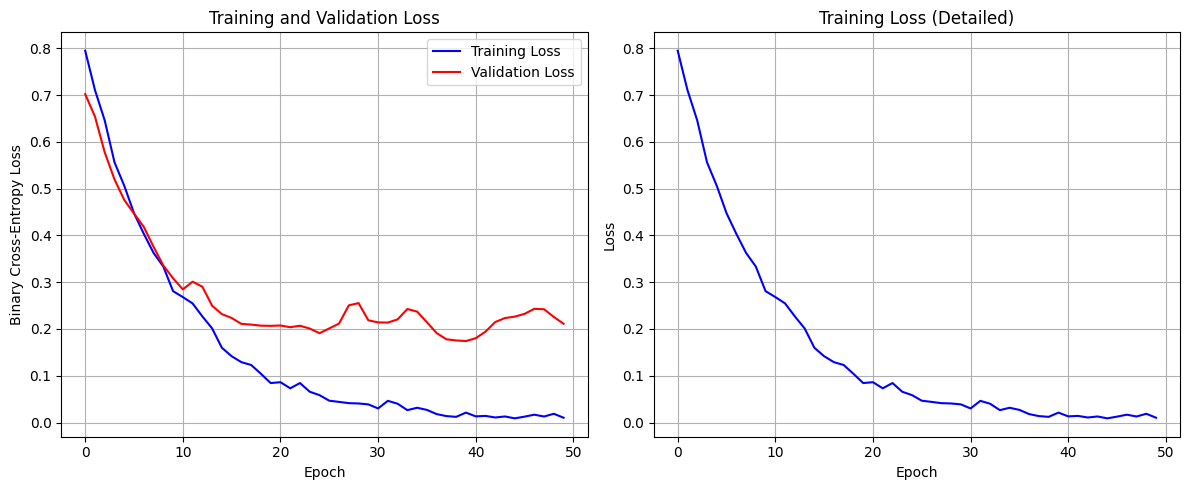


Final Training Loss: 0.0102
Final Validation Loss: 0.2111


In [15]:
# Plot training and validation losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.title('Training Loss (Detailed)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final performance
print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

## **10: Inference Function**

- Creates inference function that runs the trained model on the entire graph
- Generates final, context-aware embeddings that incorporate information from connected nodes
- Implements similarity search using cosine similarity
- Maps results back to original product IDs for interpretability

In [16]:
# Cell 10: Create inference function to get final embeddings
def get_final_embeddings(model, data):
    """Get final embeddings for all nodes after training"""

    model.eval()
    with torch.no_grad():
        # Forward pass on entire graph
        out = model(data.x_dict, data.edge_index_dict)

    return out

def find_similar_products(query_product_id, product_mapping, final_embeddings, top_k=5):
    """Find top-k similar products using cosine similarity"""

    # Get the mapped index for query product
    if query_product_id not in product_mapping:
        return f"Product {query_product_id} not found"

    query_idx = product_mapping[query_product_id]
    query_embedding = final_embeddings['product'][query_idx].unsqueeze(0)

    # Calculate cosine similarities with all products
    similarities = F.cosine_similarity(
        query_embedding,
        final_embeddings['product'],
        dim=1
    )

    # Get top-k similar products (excluding the query product itself)
    similarities[query_idx] = -1  # Exclude self
    top_indices = similarities.topk(top_k).indices
    top_similarities = similarities.topk(top_k).values

    # Map back to original product IDs
    reverse_product_mapping = {v: k for k, v in product_mapping.items()}
    similar_products = [reverse_product_mapping[idx.item()] for idx in top_indices]

    return similar_products, top_similarities.tolist()

# Get final embeddings
final_embeddings = get_final_embeddings(model, data)

print("Final embeddings generated:")
print(f"Product embeddings shape: {final_embeddings['product'].shape}")
print(f"Brand embeddings shape: {final_embeddings['brand'].shape}")
print(f"Category embeddings shape: {final_embeddings['category'].shape}")
print(f"Shop embeddings shape: {final_embeddings['shop'].shape}")

Final embeddings generated:
Product embeddings shape: torch.Size([2306, 32])
Brand embeddings shape: torch.Size([290, 32])
Category embeddings shape: torch.Size([48, 32])
Shop embeddings shape: torch.Size([1, 32])


## **11: Evaluation Function 1 - Qualitative Human Evaluation**

- Provides human-readable evaluation of the model's recommendations
- Shows actual product titles instead of just IDs for easy interpretation
- Displays similarity scores to understand confidence levels
- Allows manual inspection of whether recommendations make logical sense
- Essential for validating that the model learns meaningful relationships

In [18]:
# Cell 11: Qualitative evaluation function
def qualitative_evaluation(sample_products, product_df, product_mapping, final_embeddings):
    """Evaluate recommendations qualitatively by showing product titles"""

    print("=== QUALITATIVE EVALUATION ===")
    print("Showing recommendations for sample products:\n")

    # Create reverse mapping for product titles
    id_to_title = dict(zip(product_df['shop_product_id'], product_df['product_title_native']))

    for product_id in sample_products:
        if product_id in product_mapping:
            print(f"Query Product: {id_to_title[product_id]} (ID: {product_id})")

            similar_products, similarities = find_similar_products(
                product_id, product_mapping, final_embeddings, top_k=5
            )

            print("Top 5 Similar Products:")
            for i, (sim_id, similarity) in enumerate(zip(similar_products, similarities)):
                print(f"  {i+1}. {id_to_title[sim_id]} (ID: {sim_id}, Similarity: {similarity:.3f})")
            print("-" * 60)
        else:
            print(f"Product {product_id} not found in mapping")

# Run qualitative evaluation
sample_products = ["786feb8bd77c44ec0f6bad670445e87f", "fa0707edbf3b596e57bc4e930bf47c17", "01c78a31f94f69f3f49a0ffe8d8a94ac"]  # Samsung Galaxy M02s | 32GB , Apple iPhone 16 256GB , JBL Live 300TWS Earbuds
qualitative_evaluation(sample_products, product_df, product_mapping, final_embeddings)

=== QUALITATIVE EVALUATION ===
Showing recommendations for sample products:

Query Product: Samsung Galaxy M02s | 32GB (ID: 786feb8bd77c44ec0f6bad670445e87f)
Top 5 Similar Products:
  1. Samsung Galaxy M02 (2GB+32GB) (ID: b0ac6b0bed740d7ae53d2d3693e78ea0, Similarity: 1.000)
  2. Samsung Galaxy M02s | 64GB (ID: 0e8da4940fc835cc9325555883bdfadf, Similarity: 1.000)
  3. Samsung Galaxy M01 Core | 32GB (ID: 46e1bd9d8ba2447851b95c057b43dc44, Similarity: 1.000)
  4. Samsung Galaxy M02 (3GB+32GB) (ID: c50848fdb7a897a61c56eb7bef399272, Similarity: 1.000)
  5. Samsung Galaxy A12 (128GB) (ID: 536c3aa8e2d00cceaee2215962e605ff, Similarity: 1.000)
------------------------------------------------------------
Query Product: Apple iPhone 16 256GB (ID: fa0707edbf3b596e57bc4e930bf47c17)
Top 5 Similar Products:
  1. Apple iPhone 16 128GB (ID: 41ec8a9d7587a8855881c4c38d782c3d, Similarity: 1.000)
  2. Apple iPhone 16 Pro Max | 256GB (ID: 9014629b0aec1be0779ca82d6020225e, Similarity: 1.000)
  3. Apple iPhone

## **12: Evaluation Function 2 - t-SNE Visualization**

- Uses t-SNE to reduce high-dimensional embeddings to 2D for visualization
- Colors each point by product category to see if similar products cluster together
- Adds product IDs as labels for easy identification
- Validates whether the GNN learned to group similar products in the embedding space
- Good clustering by category indicates the model captured meaningful relationships

Creating t-SNE visualization...


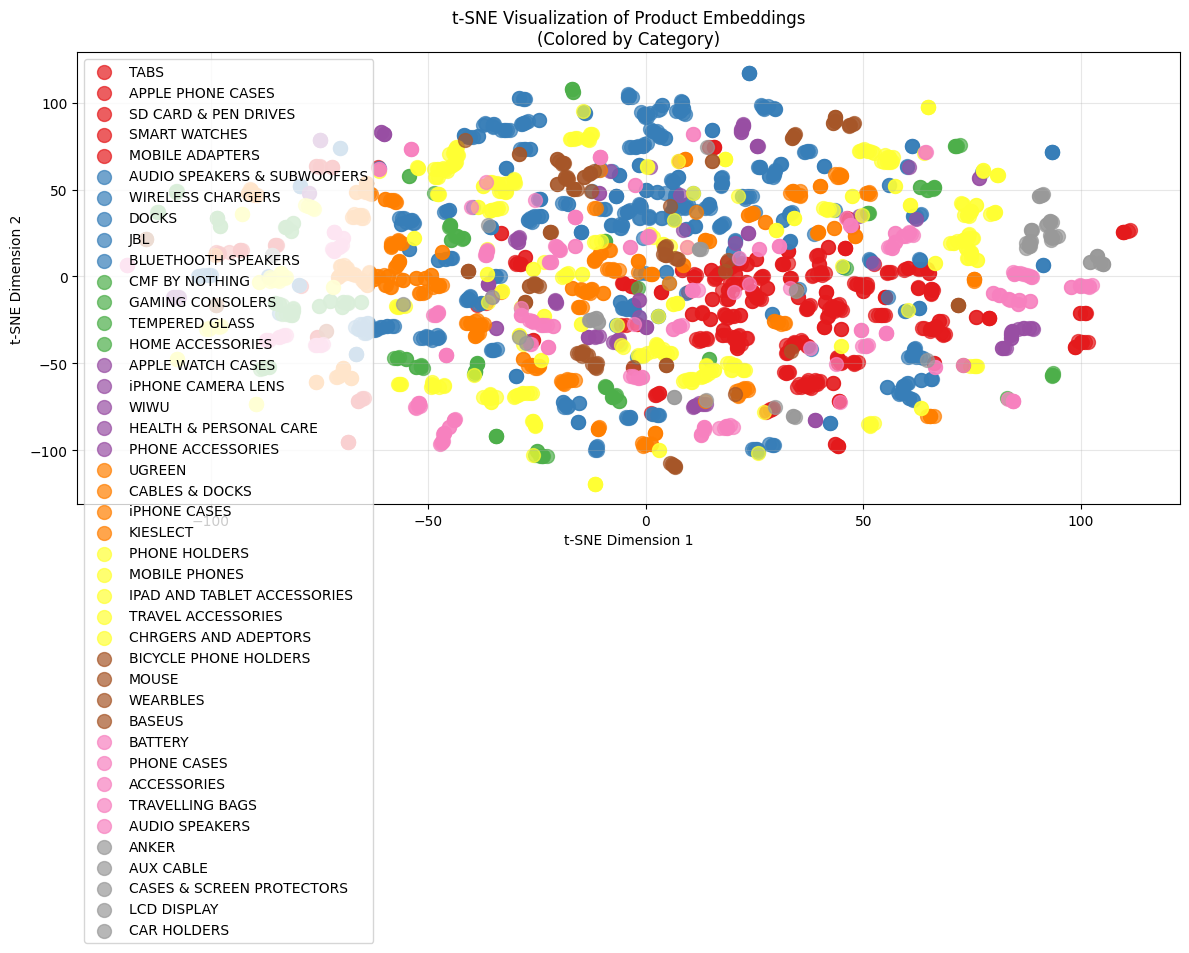

In [20]:
# Cell 12: t-SNE visualization function
def create_tsne_visualization(final_embeddings, product_df, product_category_edges_df,
                            product_mapping, category_mapping, category_df):
    """Create t-SNE visualization of product embeddings colored by category"""

    print("Creating t-SNE visualization...")

    # Get product embeddings
    product_embs = final_embeddings['product'].detach().numpy()

    # Create category labels for each product
    product_categories = {}
    for _, row in product_category_edges_df.iterrows():
        product_categories[row['shop_product_id']] = row['predicted_category_id']

    # Map to sequential indices and category names
    reverse_category_mapping = {v: k for k, v in category_mapping.items()}
    # Dynamically create category_names dictionary from category_df
    category_names = dict(zip(category_df['category_id'], category_df['category_name']))

    labels = []
    for product_id in product_df['shop_product_id']:
        cat_id = product_categories[product_id]
        labels.append(category_names[cat_id])

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=3)  # Low perplexity for small dataset
    embeddings_2d = tsne.fit_transform(product_embs)

    # Create visualization
    plt.figure(figsize=(12, 8))
    unique_labels = list(set(labels))
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

    for label, color in zip(unique_labels, colors):
        mask = [l == label for l in labels]
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   c=[color], label=label, s=100, alpha=0.7)

    # Add product labels
    # for i, (x, y) in enumerate(embeddings_2d):
    #     plt.annotate(f"{product_df.iloc[i]['shop_product_id']}",
    #                 (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.title('t-SNE Visualization of Product Embeddings\n(Colored by Category)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create t-SNE visualization
create_tsne_visualization(final_embeddings, product_df, product_category_edges_df,
                         product_mapping, category_mapping, category_df)

## **13: Evaluation Function 3 - Category Hit Rate**

- Calculates a quantitative metric to evaluate recommendation quality
- For each product, checks what percentage of its recommendations belong to the same category
- Higher hit rates indicate better category-coherent recommendations
- Provides both average performance and distribution across all products
- Serves as an automated way to measure model performance without manual inspection

Calculating Category Hit Rate @5...
Average Category Hit Rate @5: 0.847
This means 84.7% of recommendations are from the same category


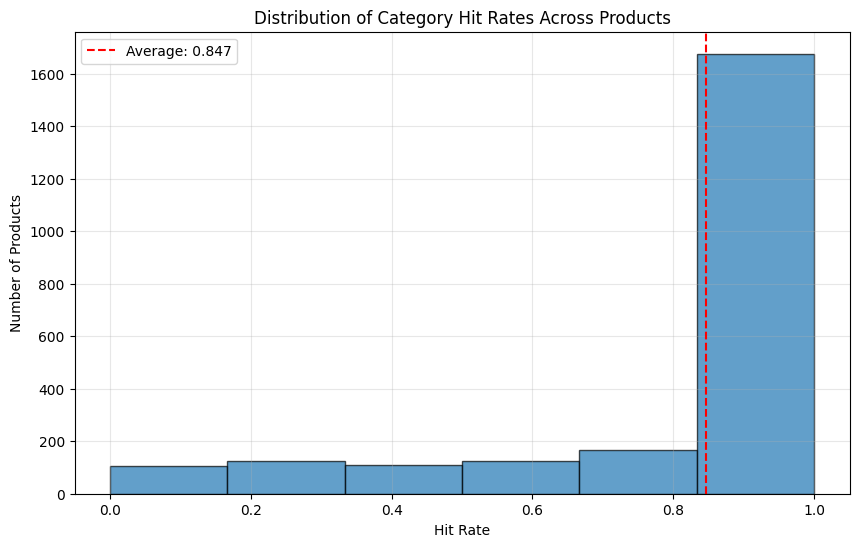

In [21]:
# Cell 13: Category hit rate evaluation
def calculate_category_hit_rate(final_embeddings, product_df, product_category_edges_df,
                               product_mapping, k=5):
    """Calculate category hit rate @K as a quantitative evaluation metric"""

    print(f"Calculating Category Hit Rate @{k}...")

    # Create product to category mapping
    product_to_category = {}
    for _, row in product_category_edges_df.iterrows():
        product_to_category[row['shop_product_id']] = row['predicted_category_id']

    hit_rates = []

    for product_id in product_df['shop_product_id']:
        # Get recommendations for this product
        similar_products, _ = find_similar_products(
            product_id, product_mapping, final_embeddings, top_k=k
        )

        # Get the category of the query product
        query_category = product_to_category[product_id]

        # Count how many recommendations are in the same category
        hits = 0
        for rec_id in similar_products:
            if rec_id in product_to_category:
                if product_to_category[rec_id] == query_category:
                    hits += 1

        hit_rate = hits / len(similar_products)
        hit_rates.append(hit_rate)

    avg_hit_rate = np.mean(hit_rates)

    print(f"Average Category Hit Rate @{k}: {avg_hit_rate:.3f}")
    print(f"This means {avg_hit_rate*100:.1f}% of recommendations are from the same category")

    return avg_hit_rate, hit_rates

# Calculate category hit rate
avg_hit_rate, individual_hit_rates = calculate_category_hit_rate(
    final_embeddings, product_df, product_category_edges_df, product_mapping, k=5
)

# Show distribution of hit rates
plt.figure(figsize=(10, 6))
plt.hist(individual_hit_rates, bins=6, alpha=0.7, edgecolor='black')
plt.title('Distribution of Category Hit Rates Across Products')
plt.xlabel('Hit Rate')
plt.ylabel('Number of Products')
plt.axvline(avg_hit_rate, color='red', linestyle='--', label=f'Average: {avg_hit_rate:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **16: Model Saving and Loading**

In [ ]:
# Cell 16: Save and load the trained model
def save_model_and_mappings(model, mappings, embeddings, filepath_prefix="gnn_recommendation"):
    """Save the trained model and all necessary mappings"""

    # Save model state
    torch.save(model.state_dict(), f"{filepath_prefix}_model.pth")

    # Save mappings and embeddings
    save_data = {
        'product_mapping': mappings[0],
        'brand_mapping': mappings[1],
        'category_mapping': mappings[2],
        'shop_mapping': mappings[3],
        'final_embeddings': embeddings,
        'model_config': {
            'hidden_dim': 64,
            'out_dim': 32,
            'embedding_dim': 384
        }
    }

    torch.save(save_data, f"{filepath_prefix}_data.pth")
    print(f"Model and data saved with prefix: {filepath_prefix}")

def load_model_and_mappings(filepath_prefix="gnn_recommendation"):
    """Load the trained model and mappings"""

    # Load data
    save_data = torch.load(f"{filepath_prefix}_data.pth")

    # Recreate model with same architecture
    loaded_model = HeteroGNN(
        hidden_dim=save_data['model_config']['hidden_dim'],
        out_dim=save_data['model_config']['out_dim']
    )
    loaded_model = to_hetero(loaded_model, data.metadata())

    # Load trained weights
    loaded_model.load_state_dict(torch.load(f"{filepath_prefix}_model.pth"))
    loaded_model.eval()

    return loaded_model, save_data

# Save the current model
save_model_and_mappings(
    model,
    (product_mapping, brand_mapping, category_mapping, shop_mapping),
    final_embeddings
)

print("Model saved successfully!")
print("\nTo load the model later, use:")
print("loaded_model, loaded_data = load_model_and_mappings('gnn_recommendation')")